# Convolutional Neural Network with PyTorch

In the first part of the MP, you have successfully implemented a convolutional neural network from scratch using NumPy. Now that you have a good understanding of the fundamentals and underlying concepts, it's time to dive into the world of deep learning frameworks.

In this part, you will learn how to implement a convolutional neural network using **[PyTorch](https://pytorch.org/)**. You will learn how to define a network architecture, instantiate a network object, train the network, and evaluate the network on the test data. We will also cover essential topics such as automatic differentiation, loss functions, and optimizers. By the end of this part, you will be able to implement, train, and evaluate neural networks using PyTorch with ease.

Get ready to explore the exciting world of PyTorch and enhance your deep learning skills!

### Submission Instructions

- You will need to submit code in this notebook file as a .py python file for grading.  You can use the menu `File -> Download as -> Python (.py)` (Jupyter Notebook) or `File -> Export Notebook As -> Export Notebook to Executable Script` (JupyterLab) to convert this notebook to a Python file, but make sure to clean up the python script (remove code form other ireelevant parts) before submitting to gradescope. We should be able to run it simply via `python <script_name.py>`. Specifically, you will need to submit two scripts (`script_custom_cnn.py` for problem 7 and `script_resnet_ft.py` for problem 8) that are entirely self-contained and replicate the predictions that you have submitted for those problems. The scripts should contain your model and be runnable to replicate your results. We will have data in the folder `dataset-v1` and your code should produce the prediction text files (i.e. `pred_custom_cnn.txt` and `pred_resnet_ft.txt` respectively).
- When submitting the prediction and the Python files, the files **must** be named exactly as instructed.
- You can make multiple submissions but only the **latest** score will be used. Keep a copy of your previous predictions in case you want to revert to them. We are not policing the number of submissions you make to the test set, but we request that you limit to 1 submission every day. You shouldn't be tuning your model on the test set.


## 0. Prerequisites

### Installing PyTorch

Before we dive into the main part of the MP, let's first make sure that you have all the necessary packages installed. If you are using Google Colab, you can skip this section as the packages are already installed. If you are using your local machine, follow the official instructions [here](https://pytorch.org/get-started/locally/). Install the GPU-compatible version if you have a compatible NVIDIA GPU. You will also need to install these additional packages: `torch torchvision Pillow tqdm matplotlib`. Run the following cell to test your installation (and import other necessary packages):


In [6]:
import os
import json
import random

from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.utils import make_grid
from matplotlib import pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

PyTorch version: 2.8.0+cu126
torchvision version: 0.23.0+cu126


### Hardware Acceleration

Graphics Processing Units (GPUs) are specialized hardware devices that can significantly speed up the training the inference of deep learning models. We strongly recommend using a GPU for this MP to save training time, though it is not required.

If you are using Google Colab, you can enable free GPU acceleration by navigating to `Runtime -> Change runtime type -> Hardware accelerator -> GPU`. If you are using your local machine, you must have a compatible GPU. Run the following cell to check if you have a compatible GPU (`cuda` for GPU):


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Downloading the Dataset

In this MP, we will be working with the filtered food subset of COCO. The dataset contains 10 different kinds of food, and each data point is a 256 by 256 RGB image. The images are cropped from the [MS-COCO dataset](https://cocodataset.org/#home) and filtered using the food superclass.The train, valid, and test splits contain 4540, 1130, and 1200 images, respectively

If you are on a Unix-based system (macOS or Linux or Google Colab), you can run the following cell to download the dataset. If you are using Windows, you should manually download the dataset from [here](https://saurabhg.web.illinois.edu/teaching/cs444/fa2025/mp2/dataset-v1.tgz) and extract the compressed file to the current directory. You should see a `dataset-v1` folder containing the dataset.

You should download the dataset first before running any codes below.


In [8]:
!wget https://saurabhg.web.illinois.edu/teaching/cs444/fa2025/mp2/dataset-v1.tgz -O dataset-v1.tgz
!tar -xf dataset-v1.tgz

--2025-10-08 22:12:06--  https://saurabhg.web.illinois.edu/teaching/cs444/fa2025/mp2/dataset-v1.tgz
Resolving saurabhg.web.illinois.edu (saurabhg.web.illinois.edu)... 18.220.149.166
Connecting to saurabhg.web.illinois.edu (saurabhg.web.illinois.edu)|18.220.149.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 92682240 (88M) [application/x-tar]
Saving to: ‘dataset-v1.tgz’

dataset-v1.tgz      100%[===================>]  88.39M  13.6MB/s    in 8.0s    

2025-10-08 22:12:16 (11.1 MB/s) - ‘dataset-v1.tgz’ saved [92682240/92682240]



## 1. Dataset

As you embark on your deep learning journey with PyTorch, one of the essential components you will encounter is the Dataset class. Datasets play a crucial role in the development of machine learning models, as they provide the necessary information for training, validation, and testing. In PyTorch, the Dataset class simplifies the process of handling data by offering a unified and efficient way to manage and preprocess your data.

The PyTorch Dataset class is an abstract class, and to utilize it, you will need to create a custom dataset by subclassing and implementing two key methods: `__len__()` and `__getitem__()`. The `__len__()` method returns the size of the dataset, while the `__getitem__()` method retrieves a sample from the dataset given an index. By providing a standardized interface for accessing your data, the Dataset class enables seamless integration with other PyTorch components, such as DataLoader, which streamlines the process of loading and batching your data during training.


In [9]:
class FoodDataset(Dataset):
    """
    Dataset containing 10 different kinds of food. Each data point is a 256 by 256 RGB image.
    The images are cropped from the MS-COCO dataset. (https://cocodataset.org/#home)
    The train, valid, and test splits contain filtered food images with remapped labels.
    """

    classes = ("bowl",
        "banana",
        "apple",
        "sandwich",
        "orange",
        "broccoli",
        "carrot",
        "hot dog",
        "pizza",
        "donut")


    def __init__(self, root, split, transform=None):
        """
        Args:
            root (str): The root directory of the dataset.
            split (str): The split to use. Can be 'train', 'val', or 'test'.
            transform (callable, optional): A function/transform that takes in an PIL image
                and returns a transformed version. See `torchvision.transforms` for examples.
        """
        self.root = root
        self.split = split
        self.transform = transform

        with open(os.path.join(root, "labels", f"{split}.json")) as f:
            self.image_list = list(json.load(f).items())

    def __len__(self):
        """
        This method is called when you do len(dataset) to get the size of the dataset.
        Usually you should implement this method.
        Returns:
            The number of data points in the split.
        """
        return len(self.image_list)

    def __getitem__(self, idx):
        """
        This method return a data point specified by the index.
        You MUST implement this method when inheriting `Dataset`.
        Args:
            idx (int): The index of the data point to get.
        Returns:
            image (Tensor): The image of the data point.
            label (int): The label of the data point.
        """
        image_path, label = self.image_list[idx]
        image = Image.open(os.path.join(self.root, "images", f"{image_path}.jpg"))
        if self.transform is not None:
            image = self.transform(image)
        return image, label

In [10]:
root = "dataset-v1"
# This transforms the PIL images to PyTorch tensors
transform = T.Compose(
    [
        T.ToTensor(),
    ]
)
test_transform = T.Compose(
    [
        T.ToTensor(),
    ]
)
train_dataset = FoodDataset(root=root, split="train", transform=transform)
valid_dataset = FoodDataset(root=root, split="val", transform=test_transform)
print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")

Train dataset size: 4540
Valid dataset size: 1130


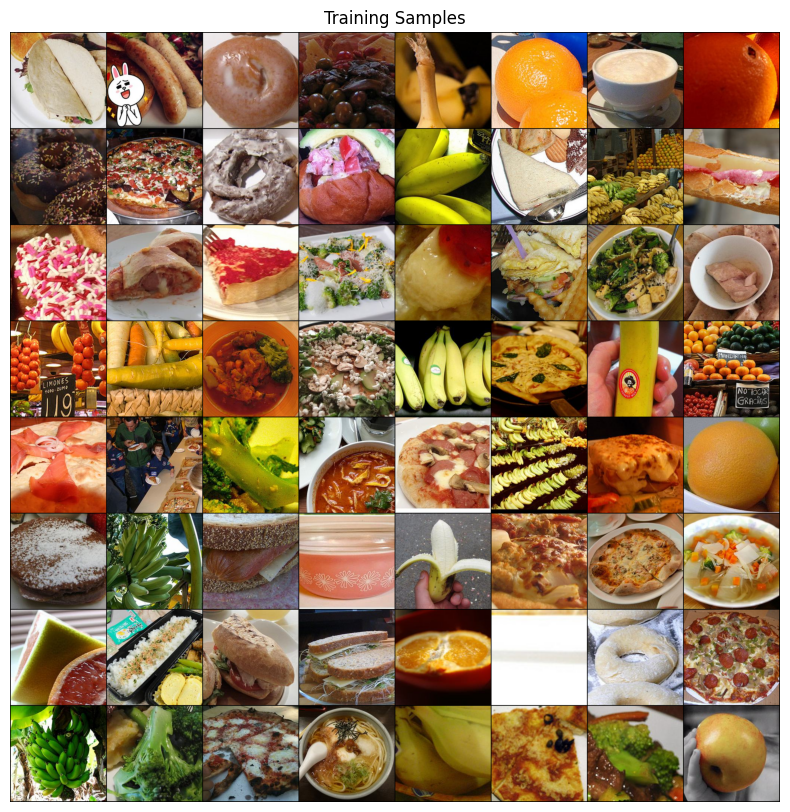

In [11]:
# Visualize some examples from the dataset.
# You can run this cell multiple times to see different examples!
n_samples = 64
indices = random.choices(range(len(train_dataset)), k=n_samples)
sample_img = [train_dataset[i][0] for i in indices]
grid_img = make_grid(sample_img, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis("off")
plt.title("Training Samples")
plt.show()

## 2. DataLoader

The PyTorch `DataLoader` works hand-in-hand with the `Dataset` class. By wrapping a `Dataset` object with a `DataLoader`, you can easily automate essential tasks such as shuffling, batching, and parallel processing. This not only saves you time and effort but also ensures that your data is loaded and prepared optimally for the training process.

One of the key features of the `DataLoader` is its support for multiprocessing. By utilizing multiple workers, `DataLoader` can efficiently parallelize the loading and preprocessing of your data, significantly reducing the overall time it takes to prepare your data for training. This is especially useful when dealing with large datasets or complex data preprocessing pipelines.

Run the following cell to create a `DataLoader` for the training and validation sets.


In [12]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
sample_img, sample_lbl = next(iter(train_loader))
print(f"Image batch shape: {sample_img.size()}")
print(f"Label batch shape: {sample_lbl.size()}")

Image batch shape: torch.Size([64, 3, 256, 256])
Label batch shape: torch.Size([64])


## 3. Model

As you delve deeper into deep learning with PyTorch, you will come across one of its most powerful and versatile components: the `nn.Module` class. This class serves as the foundation for creating and managing neural networks in PyTorch, providing a flexible and modular approach to building a wide variety of neural network architectures.

The `nn.Module` class is an abstract base class, and to leverage its power, you will need to subclass it and define your custom neural network layers and components. By implementing the `__init__()` method, you can initialize the layers and parameters of your network, while the `forward()` method defines the forward pass of your model, specifying how the input data flows through the layers to produce the output.

One of the key advantages of the `nn.Module` class is its support for automatic differentiation and backpropagation. By encapsulating your model within an `nn.Module`, you can seamlessly integrate with PyTorch's autograd system, allowing you to perform gradient-based optimization with minimal effort. Furthermore, the `nn.Module` class provides built-in methods for parameter management, serialization, and device handling, making it easy to work with complex models in a distributed or GPU-accelerated environment.

By mastering the `nn.Module`, you will be well-equipped to tackle diverse deep learning challenges and create state-of-the-art models with ease. In this introduction to PyTorch's `nn.Module`, we will guide you through the process of creating and customizing your neural networks using this powerful class. You will define a Convolutional Neural Network (CNN) by **implementing the `__init__()` and `forward()` methods**. Check PyTorch's official documentation at https://pytorch.org/docs/stable/nn.html for more information on the `nn.Module` class and other rich builtin layers.

In this cell, we define a simple multi-layer linear classifier (multi-layer percetron, or MLP) for you to get started. You will implement a convolutional neural network in the later section.


In [13]:
class MLP(nn.Module):
    """
    A simple multi-layer perceptron for classifying images in the FoodDataset.
    All models in PyTorch should inherit from `nn.Module` that provides functionality
    for automatic differentiation and weight management.
    """

    def __init__(self):
        """
        Define the layers used in model.
        """
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(3 * 256 * 256, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        """
        Forward pass of the model.
        Apply the layers defined in `__init__`.
        Args:
            x (Tensor): The input tensor of shape (N, 3, 256, 256).
        Returns:
            output (Tensor): The output tensor of shape (N, 10).
        """
        x = x.view(-1, 3 * 256 * 256)
        x = self.fc(x)
        return x

In [14]:
# Create a model instance and move it to the GPU if available
model = MLP().to(device)
print(model)
print(f"Model has {sum(p.numel() for p in model.parameters())} parameters.")

MLP(
  (fc): Sequential(
    (0): Linear(in_features=196608, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Model has 25183754 parameters.


## 4. Loss Function & Optimizer & Scheduler

Just as you have done in the previous part of this MP, we will need to define a loss function, an optimizer, and an (optional) scheduler to train our model. Luckily, PyTorch provides a wide variety of built-in [loss functions](https://pytorch.org/docs/stable/nn.html#loss-functions), [optimizers](https://pytorch.org/docs/stable/optim.html), and [schedulers](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate), making it easy to implement and experiment with different combinations. Run the following cell to create these instances.


In [15]:
lr = 1e-3
gamma = 0.9

# Define the loss function
criterion = nn.CrossEntropyLoss()
# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
# Define the learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=gamma)

## 5. Training & Validation

Now that we have defined our model, loss function, optimizer, and scheduler, we are ready to train our model! The training and validation scheme is essentially the same as you have implemented in the first part of this MP.


In [16]:
def evaluate(model, data_loader):
    """Evaluate the model on the given dataset."""
    # Set the model to evaluation mode.
    model.eval()
    correct = 0
    # The `torch.no_grad()` context will turn off gradients for efficiency.
    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            pred = output.argmax(dim=1)
            correct += (pred == labels).sum().item()
    return correct / len(data_loader.dataset)


def train(model, n_epoch, optimizer, scheduler):
    """Train the model on the given dataset."""
    for epoch in range(n_epoch):
        # Set the model to training mode.
        model.train()
        for step, (images, labels) in enumerate(train_loader):
            # 0. Prepare the data. Move the data to the device (CPU/GPU).
            images, labels = images.to(device), labels.to(device)
            # 1. Clear previous gradients.
            optimizer.zero_grad()
            # 2. Forward pass. Calculate the output of the model.
            output = model(images)
            # 3. Calculate the loss.
            loss = criterion(output, labels)
            # 4. Calculate the gradients. PyTorch does this for us!
            loss.backward()
            # 5. Update the model parameters.
            optimizer.step()
            if step % 10 == 0:
                print(f"Epoch {epoch}, Step {step}, Loss {loss.item():.4f}")
        # 6. (Optional) Update the learning rate.
        scheduler.step()
        acc = evaluate(model, valid_loader)
        print(f"Epoch {epoch}, Valid Accuracy {acc * 100:.2f}%")

In [17]:
# Train the model for 10 epochs.
# You should get an accuracy about 35% on the validation set after training.
n_epoch = 10
train(model, n_epoch, optimizer, scheduler)

Epoch 0, Step 0, Loss 2.3182
Epoch 0, Step 10, Loss 11.7760
Epoch 0, Step 20, Loss 4.7739
Epoch 0, Step 30, Loss 2.9604
Epoch 0, Step 40, Loss 2.2891
Epoch 0, Step 50, Loss 2.2268
Epoch 0, Step 60, Loss 1.9463
Epoch 0, Step 70, Loss 1.8422


100%|██████████| 18/18 [00:02<00:00,  8.69it/s]


Epoch 0, Valid Accuracy 28.76%
Epoch 1, Step 0, Loss 1.8675
Epoch 1, Step 10, Loss 2.0338
Epoch 1, Step 20, Loss 1.7562
Epoch 1, Step 30, Loss 1.9459
Epoch 1, Step 40, Loss 2.2274
Epoch 1, Step 50, Loss 1.8719
Epoch 1, Step 60, Loss 2.1264
Epoch 1, Step 70, Loss 1.9566


100%|██████████| 18/18 [00:01<00:00,  9.20it/s]


Epoch 1, Valid Accuracy 28.50%
Epoch 2, Step 0, Loss 2.0157
Epoch 2, Step 10, Loss 1.7500
Epoch 2, Step 20, Loss 1.8438
Epoch 2, Step 30, Loss 1.6229
Epoch 2, Step 40, Loss 2.1035
Epoch 2, Step 50, Loss 1.7584
Epoch 2, Step 60, Loss 1.7159
Epoch 2, Step 70, Loss 1.7549


...

Epoch 7, Valid Accuracy 38.67%
Epoch 8, Step 0, Loss 1.4141
Epoch 8, Step 10, Loss 1.7253
Epoch 8, Step 20, Loss 1.4649
Epoch 8, Step 30, Loss 1.7214
Epoch 8, Step 40, Loss 1.3213
Epoch 8, Step 50, Loss 1.4721
Epoch 8, Step 60, Loss 1.6261
Epoch 8, Step 70, Loss 1.6506


100%|██████████| 18/18 [00:01<00:00,  9.10it/s]


Epoch 8, Valid Accuracy 37.26%
Epoch 9, Step 0, Loss 1.5613
Epoch 9, Step 10, Loss 1.4642
Epoch 9, Step 20, Loss 1.5818
Epoch 9, Step 30, Loss 1.3670
Epoch 9, Step 40, Loss 1.5771
Epoch 9, Step 50, Loss 1.5018
Epoch 9, Step 60, Loss 1.4924
Epoch 9, Step 70, Loss 1.5094


100%|██████████| 18/18 [00:01<00:00,  9.14it/s]

Epoch 9, Valid Accuracy 37.61%


## 6. Convolutional Neural Network

In the previous section, you have successfully trained a MLP model on the FoodDataset. However, the performance of the model is still far from satisfactory. In this section, you will implement a convolutional neural network using the pre-defined layers in PyTorch. **Complete the `__init__` and `forward` methods**. You may refer to the [official documentation](https://pytorch.org/docs/stable/nn.html#conv2d) for more information on the `nn.Conv2d` layer.


In [20]:
class CNN(nn.Module):
    """
    A simple CNN for classifying images in the FoodDataset.
    """

    def __init__(self):
        """
        Define the layers used in model.
        Hints:
        - Checkout `nn.Conv2d`, `nn.MaxPool2d`, `nn.Linear`, `nn.ReLU`
            in the PyTorch documentation.
        - You may use `nn.Sequential` to chain multiple layers together.
        - Be careful about the input and output shapes of the layers! Print `x.size()` if unsure.

        1. 1st CNN layer:
            - 2D Convolutional with input channels 3, output channels 8, kernel size 5, stride 1, and padding 2.
            - ReLU activation.
            - 2D Max pooling with kernel size 4 and stride 4.
        2. 2nd CNN layer:
            - 2D Convolutional with input channels 8, output channels 16, kernel size 5, stride 1, and padding 2.
            - ReLU activation.
            - 2D Max pooling with kernel size 8 and stride 8.
        3. A flatten layer. The flattened feature should have shape (N, 16 * 8 * 8).
        4. A fully connected layer with 256 output units and ReLU activation.
        5. A fully connected layer with 10 output units.
        """
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 8, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(4, 4)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(8, 16, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(8, 8)
        )
        self.fc = nn.Sequential(
            nn.Linear(16 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        """
        Forward pass of the model.
        Apply the layers defined in `__init__` in order.
        Args:
            x (Tensor): The input tensor of shape (N, 3, 256, 256).
        Returns:
            output (Tensor): The output tensor of shape (N, 10).
        """
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        output = self.fc(x)
        return output

Run the following cell to test your implementation.


In [21]:
# Create a model instance and move it to the GPU if available
model = CNN().to(device)
print(model)
print(f"Model has {sum(p.numel() for p in model.parameters())} parameters.")

dummy_input = torch.randn(1, 3, 256, 256, device=device, dtype=torch.float)
output = model(dummy_input)
assert output.size() == (1, 10), f"Expected output size (1, 10), got {output.size()}!"
print("Test passed!")

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)
Model has 268794 parameters.
Test passed!


In [22]:
lr = 5e-3
gamma = 0.8
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=gamma)

# Train the model for 10 epochs.
# You should get an accuracy about 47% on the validation set.
n_epoch = 10
train(model, n_epoch, optimizer, scheduler)

Epoch 0, Step 0, Loss 2.2945
Epoch 0, Step 10, Loss 2.1906
Epoch 0, Step 20, Loss 2.1723
Epoch 0, Step 30, Loss 2.0167
Epoch 0, Step 40, Loss 2.1702
Epoch 0, Step 50, Loss 2.1094
Epoch 0, Step 60, Loss 2.1571
Epoch 0, Step 70, Loss 2.1032


100%|██████████| 18/18 [00:02<00:00,  6.79it/s]


Epoch 0, Valid Accuracy 22.92%
Epoch 1, Step 0, Loss 2.1949
Epoch 1, Step 10, Loss 2.1305
Epoch 1, Step 20, Loss 2.0719
Epoch 1, Step 30, Loss 1.9018
Epoch 1, Step 40, Loss 1.9299
Epoch 1, Step 50, Loss 1.8989
Epoch 1, Step 60, Loss 1.9840
Epoch 1, Step 70, Loss 1.7979


100%|██████████| 18/18 [00:02<00:00,  7.18it/s]


Epoch 1, Valid Accuracy 31.15%
Epoch 2, Step 0, Loss 1.9276
Epoch 2, Step 10, Loss 1.8391
Epoch 2, Step 20, Loss 1.9783
Epoch 2, Step 30, Loss 1.8560
Epoch 2, Step 40, Loss 1.8356
Epoch 2, Step 50, Loss 1.7418
Epoch 2, Step 60, Loss 1.7446
Epoch 2, Step 70, Loss 1.8446


...

Epoch 7, Valid Accuracy 40.35%
Epoch 8, Step 0, Loss 1.6285
Epoch 8, Step 10, Loss 1.4646
Epoch 8, Step 20, Loss 1.3438
Epoch 8, Step 30, Loss 1.4889
Epoch 8, Step 40, Loss 1.4917
Epoch 8, Step 50, Loss 1.7462
Epoch 8, Step 60, Loss 1.6511
Epoch 8, Step 70, Loss 1.5196


100%|██████████| 18/18 [00:02<00:00,  8.45it/s]


Epoch 8, Valid Accuracy 40.71%
Epoch 9, Step 0, Loss 1.3654
Epoch 9, Step 10, Loss 1.4573
Epoch 9, Step 20, Loss 1.5923
Epoch 9, Step 30, Loss 1.4421
Epoch 9, Step 40, Loss 1.5100
Epoch 9, Step 50, Loss 1.3349
Epoch 9, Step 60, Loss 1.4592
Epoch 9, Step 70, Loss 1.3701


100%|██████████| 18/18 [00:02<00:00,  8.29it/s]

Epoch 9, Valid Accuracy 40.88%


## 7. Hyperparameter Tuning

Though the performance has been significantly improved with a CNN model, the performance of the model is still far from satisfactory. In this section, we will explore how to tune the hyperparameters of the model to achieve better performance.
We will explore how to tune the hyperparameters of the model to achieve better performance. You may test with the following settings of the model:

- **Model architecture**: You may add more convolutional layers (`nn.Conv2d`) to the model or increase the number of hidden channels.
- **Batch normalization**: You may add batch normalization layers to the model to improve the training process. See `nn.BatchNorm2d` for more information.
- **Training hyperparameters**: You may try different hyperparameters including learning rate, number of epochs trained and batch size.
- **Data augmentation**: You may apply data augmentation techniques such as random cropping, random flipping, and random color jittering to the training set. See [here](https://pytorch.org/vision/stable/transforms.html) for more information.


  7.1 **[2 pts Autograded]**
  You can overwrite the code you have written in Section 6 with your custom CNN. You should be able to achieve an accuracy of **about 52%** on the validation set after improving the model architecture and tuning the hyperparameters. After you are satisfied with the performance of your model, run the following cells to evaluate generate predicted labels for the test set. Note that all labels we provided for the test set were set to -1. **Submit the output prediction with the name `pred_custom_cnn.txt` on Gradescope** to obtain its performance on the test set. Achieving an accuracy of 52% or higher on the **test set** will give you full credit on this problem. Also, **upload a `script_custom_cnn.py`.** The script should be runnable to replicate your results. Feel free to experiment with different settings and see how the performance changes. **You are not allowed to load any pre-trained model in this section**.

  7.2 **[2 pts Manually Graded]**
  Document the hyperparameters and/or improvement techniques you applied in your report and discuss your findings. Include _control experiments_ that measure the effectiveness of each aspect that lead to large improvements. For example, if you are trying to improve the performance of your model by adding more convolutional layers, you should include a control experiment that measures the performance of the model with and without the additional convolutional layers. It is insightful to do backward ablations: starting with your final model, remove each modification you made one at a time to measure its contribution to the final performance. Consider presenting your results in tabular form along with a discussion of the results.


In [34]:
# Modify the model architecture, training hyperparameters, and use data augmentation techniques etc. to improve the performance.
# Dataset
root = "dataset-v1"


transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor()
])

# Standard test transform
test_transform = T.Compose([
    T.ToTensor()
])

train_dataset = FoodDataset(root=root, split="train", transform=transform)
valid_dataset = FoodDataset(root=root, split="val", transform=test_transform)
print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")


batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Model
class CNN(nn.Module):
    """
    A simple CNN for classifying images in the FoodDataset.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(4, 4)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(4, 4)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(4, 4)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        output = self.fc(x)
        return output


model = CNN().to(device)
print(model)
print(f"Model has {sum(p.numel() for p in model.parameters())} parameters.")

# Improved training hyperparameters
lr = 1e-3
gamma = 0.9

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=gamma)

# Training for more epochs
n_epoch = 25
train(model, n_epoch, optimizer, scheduler)


Train dataset size: 4540
Valid dataset size: 1130
CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=256, b

100%|██████████| 18/18 [00:02<00:00,  7.57it/s]


Epoch 0, Valid Accuracy 37.96%
Epoch 1, Step 0, Loss 1.7580
Epoch 1, Step 10, Loss 1.8678
Epoch 1, Step 20, Loss 2.0233
Epoch 1, Step 30, Loss 1.6706
Epoch 1, Step 40, Loss 1.6876
Epoch 1, Step 50, Loss 1.7018
Epoch 1, Step 60, Loss 1.7664
Epoch 1, Step 70, Loss 1.9584


100%|██████████| 18/18 [00:02<00:00,  6.35it/s]


Epoch 1, Valid Accuracy 41.59%
Epoch 2, Step 0, Loss 1.6844
Epoch 2, Step 10, Loss 1.8039
Epoch 2, Step 20, Loss 1.6883
Epoch 2, Step 30, Loss 1.7503
Epoch 2, Step 40, Loss 1.8434
Epoch 2, Step 50, Loss 1.8077
Epoch 2, Step 60, Loss 1.5852
Epoch 2, Step 70, Loss 1.7983


...

Epoch 22, Valid Accuracy 58.32%
Epoch 23, Step 0, Loss 1.1499
Epoch 23, Step 10, Loss 1.4051
Epoch 23, Step 20, Loss 1.1266
Epoch 23, Step 30, Loss 1.0929
Epoch 23, Step 40, Loss 1.0637
Epoch 23, Step 50, Loss 1.0543
Epoch 23, Step 60, Loss 1.2005
Epoch 23, Step 70, Loss 1.0446


100%|██████████| 18/18 [00:02<00:00,  7.63it/s]


Epoch 23, Valid Accuracy 57.88%
Epoch 24, Step 0, Loss 1.1100
Epoch 24, Step 10, Loss 1.0607
Epoch 24, Step 20, Loss 1.0112
Epoch 24, Step 30, Loss 1.0737
Epoch 24, Step 40, Loss 1.2313
Epoch 24, Step 50, Loss 1.2905
Epoch 24, Step 60, Loss 1.1286
Epoch 24, Step 70, Loss 0.9767


100%|██████████| 18/18 [00:02<00:00,  7.78it/s]

Epoch 24, Valid Accuracy 56.81%


In [35]:
def inference(model, data_loader, output_fn="predictions.txt"):
    """Generate predicted labels for the test set."""
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in tqdm(data_loader):
            images = images.to(device)
            output = model(images)
            pred = output.argmax(dim=1)
            predictions.extend(pred.cpu().numpy())
    with open(output_fn, "w") as f:
        for pred in predictions:
            f.write(f"{pred}\n")
    print(f"Predictions saved to {output_fn}")
    return predictions


test_dataset = FoodDataset(root=root, split="test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
inference(model, test_loader, "pred_custom_cnn.txt")

100%|██████████| 19/19 [00:02<00:00,  7.69it/s]

Predictions saved to pred_custom_cnn.txt


[np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(7),
 np.int64(8),
 np.int64(8),
 np.int64(1),
 np.int64(6),
 np.int64(6),
 np.int64(8),
 np.int64(8),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(3),
 np.int64(8),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(8),
 np.int64(3),
 np.int64(3),
 np.int64(8),
 np.int64(5),
 np.int64(5),
 np.int64(8),
 np.int64(8),
 np.int64(0),
 np.int64(5),
 np.int64(5),
 np.int64(8),
 np.int64(3),
 np.int64(5),
 np.int64(3),
 np.int64(3),
 np.int64(9),
 np.int64(4),
 np.int64(1),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(4),
 np.int64(8),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.in

## 8. Finetuning Pre-Trained ResNet-18 Model

In the previous section, you have successfully trained a CNN model from scratch. However, training a model from scratch is often time-consuming and computationally expensive. Luckily, we can leverage the power of transfer learning to speed up the training process and achieve better performance. In this section, we will explore how to finetune a pre-trained model using PyTorch.

In this section, you can use the [ResNet-18](https://arxiv.org/abs/1512.03385) model pre-trained on the [ImageNet](https://www.image-net.org/) dataset. Finetune the model on the FoodDataset and evaluate the model on the test set. See [here](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) for more information on the pre-trained models provided by PyTorch.

8.1 **[2 pts Autograded]**
You need to get an accuracy of **81%** on the test set in order to receive the full points. **Submit the output prediction with the name `pred_resnet_ft.txt` on Gradescope** to obtain its performance on the test set. Also, **upload a `script_resnet_ft.py` file of your finetuning code on Gradescope**. The script should be runnable to replicate your results.

8.2 **[0.5 pt Extra credit, manually graded]**
We have set up another leaderboard for this section. Feel free to experiment with different settings and see how the performance changes. You can only use pre-trained ResNet-18 model in this section. Students with the top 5 highest accuracy will receive 0.5 point extra credit. Late submissions (i.e. after Oct 9 2025 11:59PM) will not be eligible for this extra credit. We will be looking over and running your script to confirm that your code actually results in the predictions you submitted. So make sure to read up on how to properly seed your code to make it [reproducible](https://docs.pytorch.org/docs/stable/notes/randomness.html).


In [38]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torchvision.transforms as T

resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

for name, param in resnet.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

resnet = resnet.to(device)

train_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor()
])
test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor()
])

train_dataset = FoodDataset(root=root, split="train", transform=train_transform)
valid_dataset = FoodDataset(root=root, split="val", transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

n_epoch = 25
train(resnet, n_epoch, optimizer, scheduler)


Epoch 0, Step 0, Loss 2.4732
Epoch 0, Step 10, Loss 1.3899
Epoch 0, Step 20, Loss 0.5971
Epoch 0, Step 30, Loss 1.1051
Epoch 0, Step 40, Loss 0.7512
Epoch 0, Step 50, Loss 0.7764
Epoch 0, Step 60, Loss 0.9063
Epoch 0, Step 70, Loss 0.6343


100%|██████████| 18/18 [00:02<00:00,  6.92it/s]


Epoch 0, Valid Accuracy 77.70%
Epoch 1, Step 0, Loss 0.3631
Epoch 1, Step 10, Loss 0.2745
Epoch 1, Step 20, Loss 0.2914
Epoch 1, Step 30, Loss 0.4442
Epoch 1, Step 40, Loss 0.3602
Epoch 1, Step 50, Loss 0.2397
Epoch 1, Step 60, Loss 0.2824
Epoch 1, Step 70, Loss 0.4583


100%|██████████| 18/18 [00:02<00:00,  6.94it/s]


Epoch 1, Valid Accuracy 79.47%
Epoch 2, Step 0, Loss 0.0898
Epoch 2, Step 10, Loss 0.1218
Epoch 2, Step 20, Loss 0.1285
Epoch 2, Step 30, Loss 0.0982
Epoch 2, Step 40, Loss 0.1032
Epoch 2, Step 50, Loss 0.0809
Epoch 2, Step 60, Loss 0.1629
Epoch 2, Step 70, Loss 0.0921


...

Epoch 22, Valid Accuracy 81.77%
Epoch 23, Step 0, Loss 0.0012
Epoch 23, Step 10, Loss 0.0027
Epoch 23, Step 20, Loss 0.0008
Epoch 23, Step 30, Loss 0.0010
Epoch 23, Step 40, Loss 0.0013
Epoch 23, Step 50, Loss 0.0016
Epoch 23, Step 60, Loss 0.0030
Epoch 23, Step 70, Loss 0.0009


100%|██████████| 18/18 [00:02<00:00,  6.46it/s]


Epoch 23, Valid Accuracy 81.33%
Epoch 24, Step 0, Loss 0.0011
Epoch 24, Step 10, Loss 0.0011
Epoch 24, Step 20, Loss 0.0008
Epoch 24, Step 30, Loss 0.0024
Epoch 24, Step 40, Loss 0.0013
Epoch 24, Step 50, Loss 0.0034
Epoch 24, Step 60, Loss 0.0021
Epoch 24, Step 70, Loss 0.0046


100%|██████████| 18/18 [00:02<00:00,  7.04it/s]

Epoch 24, Valid Accuracy 81.50%


In [39]:
test_dataset = FoodDataset(root=root, split="test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
inference(resnet, test_loader, "pred_resnet_ft.txt")

100%|██████████| 19/19 [00:03<00:00,  5.67it/s]

Predictions saved to pred_resnet_ft.txt


[np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(5),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(7),
 np.int64(7),
 np.int64(8),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(5),
 np.int64(8),
 np.int64(5),
 np.int64(7),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(3),
 np.int64(8),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(8),
 np.int64(9),
 np.int64(8),
 np.int64(3),
 np.int64(3),
 np.int64(8),
 np.int64(6),
 np.int64(6),
 np.int64(0),
 np.int64(8),
 np.int64(3),
 np.int64(6),
 np.int64(5),
 np.int64(8),
 np.int64(3),
 np.int64(5),
 np.int64(8),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(4),
 np.int64(8),
 np.int64(4),
 np.int64(2),
 np.int64(4),
 np.in

## 9. Error Analysis with Confusion Matrix

Now that you have trained a fine-tuned ResNet-18 model, you will perform a deeper analysis of its performance. Understanding the model's failure modes is crucial for future improvements and for gaining insight into the dataset.
In this section, you will generate a confusion matrix for your best performing Resnet-18 model on the validation set.

A [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) is used to evaluate a classifier by showing the counts of ground truth vs. predicted labels. The rows, indexed by i represent the actual classes and the columns, indexed by j represent the predicted classes. Any matrix entry C_{i,j} is the number of examples that have a ground truth i but were predicted to be class j. Correct classifications lie on the diagonal of the matrix, while all off-diagonal entries represent misclassifications.


9.1 **[2 pt Manually Graded]** Complete the `create_confusion_matrix()` function given below. Use it to:

1. **Generate a confusion matrix** for your best performing Resnet-18 model on the validation set
2. **Identify the most confused class pair** (i.e., the entry in the confusion matrix that has the highest count and corresponds to a mistake )
3. **Visualize 5 sample images** from the validation set that were misclassified for the above, most frequent error.

In your report, include the confusion matrix plot and the five sample images. Accompany them with a brief discussion analyzing why the model might be confusing these classes.


In [41]:
# Helper functions for plotting confusion matrix and visualizing misclassified images
import numpy as np

def plot_confusion_matrix(confusion_matrix, class_names):
    """
    Plot the confusion matrix calculated by `create_confusion_matrix` using matplotlib.

    Args:
        confusion_matrix (numpy.ndarray): 2D array of shape (n_classes, n_classes)
        class_names (list): List of class names for labeling
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(confusion_matrix, cmap='Blues')

    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, str(confusion_matrix[i, j]),
                    ha='center', va='center', fontsize=12)

    plt.title('Confusion Matrix on Validation Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def get_predictions_and_labels(model, data_loader):
    """Get predictions and true labels for confusion matrix analysis."""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_predictions), np.array(all_labels)

def get_misclassified_samples(dataset, predictions, labels, true_class_idx, pred_class_idx, num_samples=5):
    """Get sample images that were misclassified from true_class to pred_class."""
    # Find indices where true label is true_class_idx and prediction is pred_class_idx
    misclassified_mask = (labels == true_class_idx) & (predictions == pred_class_idx)
    misclassified_indices = np.where(misclassified_mask)[0]

    print(f"Found {len(misclassified_indices)} misclassified samples")

    # Select up to num_samples
    selected_indices = misclassified_indices[:num_samples]

    sample_images = []
    for idx in selected_indices:
        image, _ = dataset[idx]  # Get image from dataset
        sample_images.append(image)

    return sample_images, selected_indices

def visualize_misclassified_images(images, true_class_name, pred_class_name, class_names):
    """Visualize misclassified images with true and predicted labels."""
    n_images = len(images)
    fig, axes = plt.subplots(1, n_images, figsize=(15, 3))

    if n_images == 1:
        axes = [axes]

    for i, img in enumerate(images):
        # Convert tensor to numpy and transpose for matplotlib
        if isinstance(img, torch.Tensor):
            img_np = img.permute(1, 2, 0).numpy()
        else:
            img_np = img

        axes[i].imshow(img_np)
        axes[i].set_title(f'True: {true_class_name}\nPred: {pred_class_name}', fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f'Misclassified Images: {true_class_name} → {pred_class_name}', fontsize=14)
    plt.tight_layout()
    plt.show()


In [42]:
best_model = resnet  # Change this to your best model
best_model.eval()
# Get predictions and labels for validation set
val_predictions, val_labels = get_predictions_and_labels(best_model, valid_loader)

100%|██████████| 18/18 [00:02<00:00,  6.77it/s]


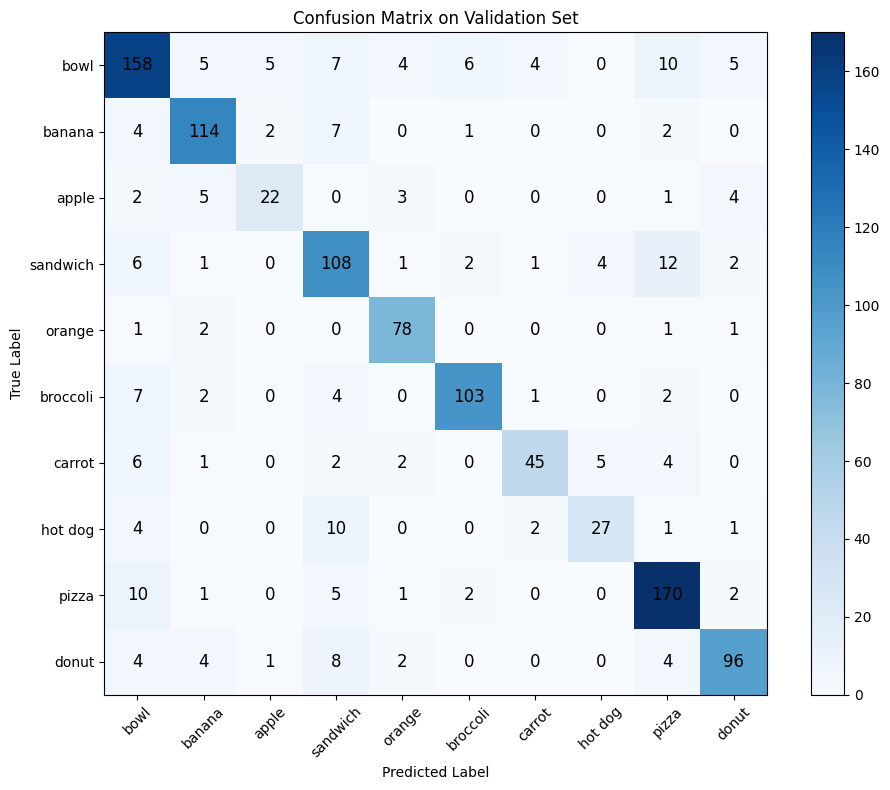

Confusion Matrix Shape: (10, 10)
Total predictions: 1130


In [44]:
def create_confusion_matrix(y_true, y_pred, num_classes):
    """
    Define a function to create a confusion matrix using ground truth labels and predicted labels.
    Hint: Use `np.zeros` to initialize the confusion matrix.
    Args:
        y_true: Array of true labels
        y_pred: Array of predicted labels
        num_classes: Number of classes

    Returns:
        confusion_matrix: 2D numpy array of shape (num_classes, num_classes)
    """
    import numpy as np
    cm = np.zeros((num_classes, num_classes), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    return cm

# Create and plot confusion matrix
class_names = FoodDataset.classes
num_classes = len(class_names)

cm = create_confusion_matrix(val_labels, val_predictions, num_classes)
plot_confusion_matrix(cm, class_names)

print(f"Confusion Matrix Shape: {cm.shape}")
print(f"Total predictions: {cm.sum()}")

Found 158 misclassified samples


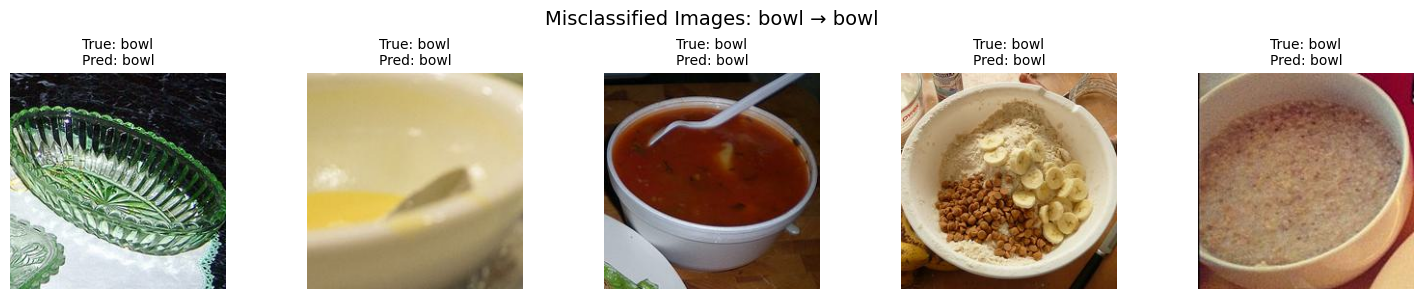

In [45]:
# Look at the confusion matrix above and identify the largest entry corresponding to misclassifications

# Example values - replace these with your observations:
most_confused_true = 0 # Replace with actual index
most_confused_pred = 0  # Replace with actual index
# Get indices ofmisclassified samples
misclassified_images, sample_indices = get_misclassified_samples(
    valid_dataset, val_predictions, val_labels,
    most_confused_true, most_confused_pred, num_samples=5
)
# Visualize the misclassified images
true_class_name = class_names[most_confused_true]
pred_class_name = class_names[most_confused_pred]

visualize_misclassified_images(
    misclassified_images, true_class_name, pred_class_name, class_names
)
